**Basics of Data Analysis**

**IMPORTING ALL NECESSARY LIBRARIES**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

**DATA LOADING**

In [2]:
df = pd.read_csv('/content/Chocolate_Sales.csv')
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04-Jan-22,"$5,320",180
1,Van Tuxwell,India,85% Dark Bars,01-Aug-22,"$7,896",94
2,Gigi Bohling,India,Peanut Butter Cubes,07-Jul-22,"$4,501",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27-Apr-22,"$12,726",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24-Feb-22,"$13,685",184


In [3]:
df.shape    # detrmining the total number of rows and columns

(1094, 6)

In [4]:
df.info()   # determing the structure of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   1094 non-null   object
 1   Country        1094 non-null   object
 2   Product        1094 non-null   object
 3   Date           1094 non-null   object
 4   Amount         1094 non-null   object
 5   Boxes Shipped  1094 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 51.4+ KB


In [5]:
df.describe()   # statistical overview of the dataset it will only work with int or float data types

,Boxes Shipped
count,1094.000000
mean,161.797989
std,121.544145
min,1.000000
25%,70.000000
50%,135.000000
75%,228.750000
max,709.000000


In [6]:
# since we have no null values in the dataset hence we are not dropping any rows

In [7]:
# finding unique values in 'Product' field
print(df['Product'].value_counts())
print(f'\nThere are {df['Product'].value_counts().shape[0]} unique chocolates present in the dataset')

Product
Eclairs                 60
50% Dark Bites          60
Smooth Sliky Salty      59
White Choc              58
Drinking Coco           56
Spicy Special Slims     54
Organic Choco Syrup     52
85% Dark Bars           50
Fruit & Nut Bars        50
After Nines             50
Peanut Butter Cubes     49
99% Dark & Pure         49
Milk Bars               49
Raspberry Choco         48
Almond Choco            48
Orange Choco            47
Mint Chip Choco         45
Manuka Honey Choco      45
Caramel Stuffed Bars    43
70% Dark Bites          42
Baker's Choco Chips     41
Choco Coated Almonds    39
Name: count, dtype: int64

There are 22 unique chocolates present in the dataset


In [8]:
# finding unique values in 'Country' field
print(df['Country'].value_counts())
print(f'\nThere are {df['Country'].value_counts().shape[0]} unique countries present in the dataset')

Country
Australia      205
India          184
USA            179
UK             178
Canada         175
New Zealand    173
Name: count, dtype: int64

There are 6 unique countries present in the dataset


**DATA CLEANING**

In [9]:
# cleaning the Amount column by converting the data type from object to float

df['Amount'] = df['Amount'].replace('[$,]', '', regex=True).astype(float)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sales Person   1094 non-null   object 
 1   Country        1094 non-null   object 
 2   Product        1094 non-null   object 
 3   Date           1094 non-null   object 
 4   Amount         1094 non-null   float64
 5   Boxes Shipped  1094 non-null   int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 51.4+ KB


In [11]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04-Jan-22,5320.0,180
1,Van Tuxwell,India,85% Dark Bars,01-Aug-22,7896.0,94
2,Gigi Bohling,India,Peanut Butter Cubes,07-Jul-22,4501.0,91
3,Jan Morforth,Australia,Peanut Butter Cubes,27-Apr-22,12726.0,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24-Feb-22,13685.0,184


**DATA MANIPULATION**

In [12]:
# finding all records where the amount is greater than $15,000
conditional_dataset_1 = df[df['Amount'] > 15000.0]
conditional_dataset_1

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
57,Brien Boise,Canada,99% Dark & Pure,18-May-22,16793.0,416
58,Barr Faughny,Australia,Fruit & Nut Bars,30-Jun-22,15421.0,55
66,Van Tuxwell,Australia,Organic Choco Syrup,10-Aug-22,19453.0,14
119,Kelci Walkden,USA,Manuka Honey Choco,16-Feb-22,17318.0,87
126,Dotty Strutley,UK,Almond Choco,28-Jul-22,16114.0,96
135,Van Tuxwell,India,Organic Choco Syrup,16-May-22,19929.0,174
212,Marney O'Breen,UK,Smooth Sliky Salty,13-May-22,18991.0,88
257,Ches Bonnell,India,Organic Choco Syrup,08-Mar-22,16569.0,99
330,Kelci Walkden,Canada,Milk Bars,07-Jul-22,16016.0,28
372,Dotty Strutley,USA,Caramel Stuffed Bars,15-Apr-22,16982.0,76


In [13]:
conditional_dataset_1.shape

(33, 6)

In [14]:
# finding all records where the amount is greater than $15,000 and the product is 'Organic Choco Syrup'
conditional_dataset_2 = df[(df['Amount'] > 15000.0) & (df['Product'].isin(['Organic Choco Syrup', 'Mint Chip Choco', 'Milk Bars']))]
conditional_dataset_2

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
66,Van Tuxwell,Australia,Organic Choco Syrup,10-Aug-22,19453.0,14
135,Van Tuxwell,India,Organic Choco Syrup,16-May-22,19929.0,174
257,Ches Bonnell,India,Organic Choco Syrup,08-Mar-22,16569.0,99
330,Kelci Walkden,Canada,Milk Bars,07-Jul-22,16016.0,28
395,Brien Boise,USA,Organic Choco Syrup,25-May-22,16233.0,138
434,Jan Morforth,New Zealand,Mint Chip Choco,30-Jun-22,18340.0,285
437,Kaine Padly,USA,Milk Bars,15-Jun-22,15491.0,58
462,Karlen McCaffrey,USA,Mint Chip Choco,15-Feb-22,15652.0,53
510,Oby Sorrel,New Zealand,Organic Choco Syrup,17-Feb-22,15316.0,270
609,Jan Morforth,Australia,Mint Chip Choco,22-Feb-22,17626.0,103


**DATA VISULAIZATION**

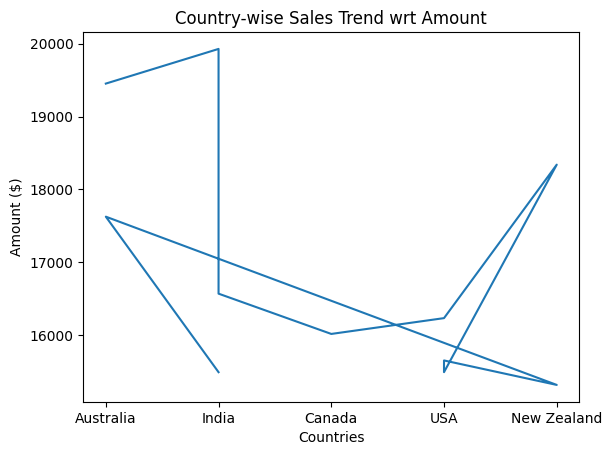

In [15]:
plt.plot(conditional_dataset_2['Country'], conditional_dataset_2['Amount'])
plt.title('Country-wise Sales Trend wrt Amount')
plt.xlabel('Countries')
plt.ylabel('Amount ($)')
plt.show()

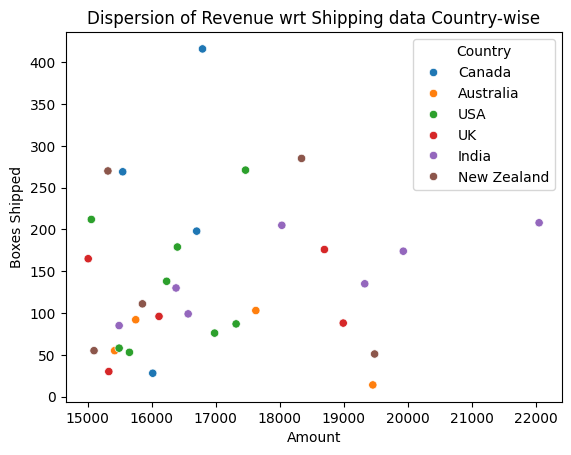

In [16]:
sns.scatterplot(x='Amount', y='Boxes Shipped', hue='Country', data=conditional_dataset_1)
plt.title('Dispersion of Revenue wrt Shipping data Country-wise')
plt.show()

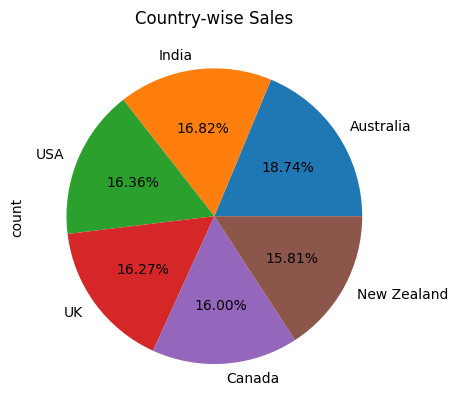

In [17]:
df['Country'].value_counts().plot(kind='pie', autopct='%0.2f%%')
plt.title('Country-wise Sales')
plt.show()

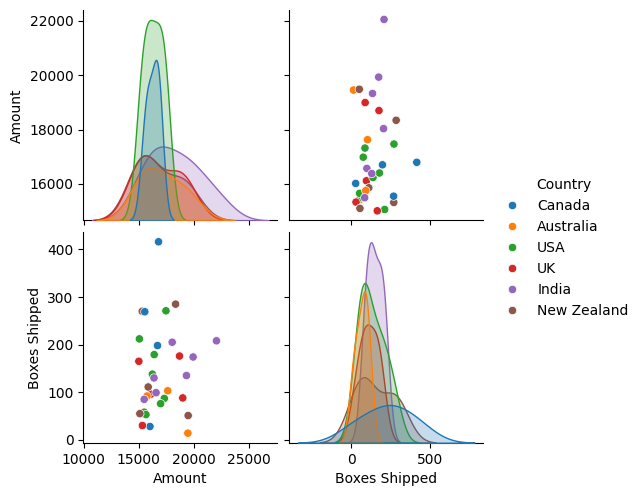

In [18]:
sns.pairplot(conditional_dataset_1, hue='Country')
plt.show()

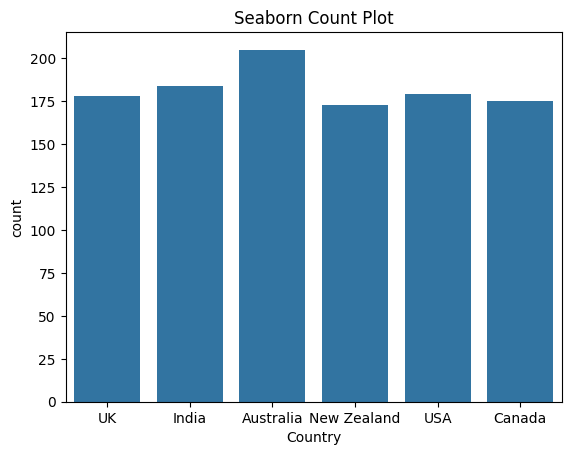

In [19]:
sns.countplot(x='Country', data=df)
plt.title('Seaborn Count Plot')
plt.show()

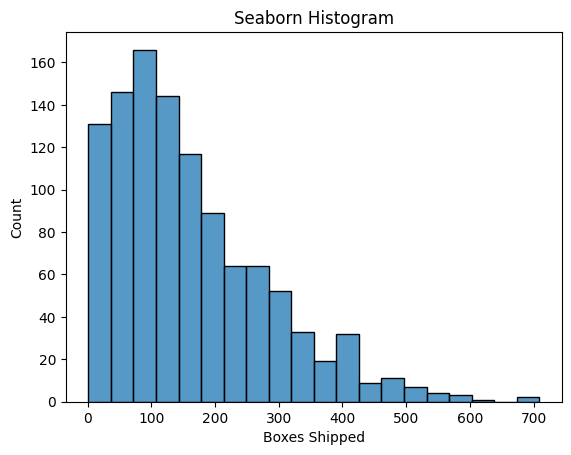

In [20]:
sns.histplot(df['Boxes Shipped'], bins=20)
plt.title('Seaborn Histogram')
plt.show()

**FEATURE ENGINEERING**

In [21]:
df['Revenue per Box'] = df['Amount'] / df['Boxes Shipped']
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped,Revenue per Box
0,Jehu Rudeforth,UK,Mint Chip Choco,04-Jan-22,5320.0,180,29.555556
1,Van Tuxwell,India,85% Dark Bars,01-Aug-22,7896.0,94,84.000000
2,Gigi Bohling,India,Peanut Butter Cubes,07-Jul-22,4501.0,91,49.461538
3,Jan Morforth,Australia,Peanut Butter Cubes,27-Apr-22,12726.0,342,37.210526
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24-Feb-22,13685.0,184,74.375000


In [22]:
df['Boxes_Shipped_Groups'] = pd.cut(df['Boxes Shipped'], bins=[0, 236, 472, 709], labels=['Minimum Sales', 'Average Sales', 'Maximum Sales'])
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped,Revenue per Box,Boxes_Shipped_Groups
0,Jehu Rudeforth,UK,Mint Chip Choco,04-Jan-22,5320.0,180,29.555556,Minimum Sales
1,Van Tuxwell,India,85% Dark Bars,01-Aug-22,7896.0,94,84.000000,Minimum Sales
2,Gigi Bohling,India,Peanut Butter Cubes,07-Jul-22,4501.0,91,49.461538,Minimum Sales
3,Jan Morforth,Australia,Peanut Butter Cubes,27-Apr-22,12726.0,342,37.210526,Average Sales
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24-Feb-22,13685.0,184,74.375000,Minimum Sales


In [23]:
df['Boxes_Shipped_Groups'].value_counts()

,count
Boxes_Shipped_Groups,
Minimum Sales,840
Average Sales,231
Maximum Sales,23


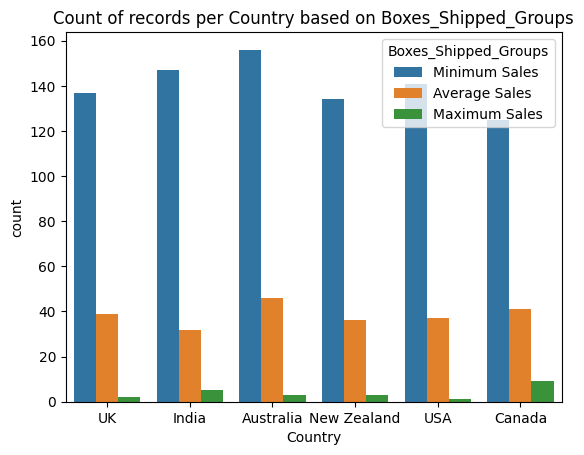

In [24]:
sns.countplot(x='Country', hue='Boxes_Shipped_Groups', data=df)
plt.title('Count of records per Country based on Boxes_Shipped_Groups')
plt.show()